In [1]:
import numpy as np
import pandas as pd
import h5py
import os, sys
import torch
from transformers import AutoTokenizer
os.chdir('../../results/pseudo_gene/splice_junctions/')
import matplotlib.pyplot as plt

In [2]:
def chunks(lst, n):
    return [''.join(lst[i:i+n]).upper() for i in range(0, len(lst), n)]
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [3]:
junctions = ["start_sites", "stop_sites", "donor", "acceptor"]
cad2_suffixes = {
    "start_sites": "filtered_ATG",
    "stop_sites": "filtered_TAG", 
    "donor": "filtered_GT",
    "acceptor": "filtered_AG"
}

evo2_suffixes = {
    "start_sites": "evo2_7b_ntokens_3",
    "stop_sites": "evo2_7b_ntokens_3",
    "donor": "filtered_evo2_7b_ntokens_2",
    "acceptor": "filtered_evo2_7b_ntokens_2"
}

taxa = "B73_"
fnames_cad2 = [f"{taxa}{type}_{cad2_suffixes[type]}.h5" for type in junctions]
fnames_evo2 = [f"{taxa}{type}_{evo2_suffixes[type]}.tsv" for type in junctions]
fnames_label = [f"{taxa}{type}_filtered_labels.tsv" for type in junctions]

In [4]:
labels_dict = {}
for idx, junction in enumerate(junctions):
    label = pd.read_csv(fnames_label[idx], sep='\t')
    with h5py.File(fnames_cad2[idx], 'a') as hf:
        plantcad2_logits = torch.tensor(hf['predicted_logits'][:])
        true_ids = torch.tensor(hf['true_token_ids'][:])
    predicted_tokens = tokenizer.convert_ids_to_tokens(torch.argmax(plantcad2_logits, dim=1))
    if junction in ['start_sites', 'stop_sites']:
        predicted_codon = chunks(predicted_tokens, n = 3)
        true_tokens = chunks(tokenizer.convert_ids_to_tokens(true_ids), 3)
    else:
        predicted_codon = chunks(predicted_tokens, n = 2)
        true_tokens = chunks(tokenizer.convert_ids_to_tokens(true_ids), 2)
    label['true_tokens'] = true_tokens
    label['predicted_codon_plantcad2'] = predicted_codon
    predicted_codon = pd.read_csv(fnames_evo2[idx], sep='\t', header=None)
    label['predicted_codon_evo2'] = predicted_codon[0]
    labels_dict[junction] = label

## Visualization

In [5]:
label_order = ['Core Gene', 'Near-Core Gene', 'Dispensable Gene', 'Private Gene']
def calculate_accuracies(df, order=label_order):
    results = {}
    for label in order: 
        if label in df['Label'].values:  # Check if the label exists in the data
            group = df[df['Label'] == label]
            
            # Calculate accuracy for plantcad2
            plantcad2_accuracy = (group['predicted_codon_plantcad2'] == group['true_tokens']).mean()
            
            # Calculate accuracy for evo2
            evo2_accuracy = (group['predicted_codon_evo2'] == group['true_tokens']).mean()
            
            results[label] = {
                'plantcad2': plantcad2_accuracy,
                'evo2': evo2_accuracy
            }
    
    return results

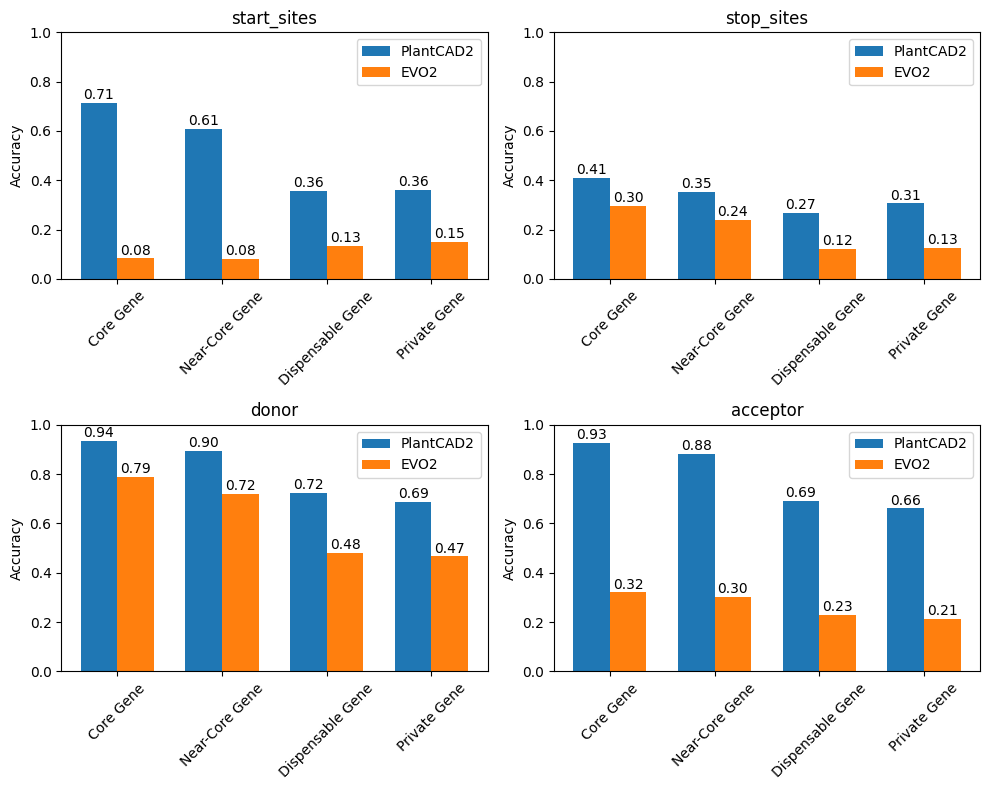

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes_flat = axes.flatten()

for idx, (dataset_name, df) in enumerate(labels_dict.items()):
    ax = axes_flat[idx]
    
    accuracies = calculate_accuracies(df)
    
    labels = label_order
    plantcad2_scores = [accuracies[label]['plantcad2'] for label in labels]
    evo2_scores = [accuracies[label]['evo2'] for label in labels]
    
    x = range(len(labels))
    width = 0.35
    rects1 = ax.bar([i - width/2 for i in x], plantcad2_scores, width, label='PlantCAD2')
    rects2 = ax.bar([i + width/2 for i in x], evo2_scores, width, label='EVO2')
    
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{dataset_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.legend()
    ax.set_ylim(0, 1)
    
    # Add value labels on bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(rect.get_x() + rect.get_width() / 2, height),
                       xytext=(0, 0.5),
                       textcoords="offset points",
                       ha='center', va='bottom')
    
    autolabel(rects1)
    autolabel(rects2)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('../../../pipelines/pseudo_gene/Token_accuracy_comparison.pdf', format='pdf',bbox_inches='tight')
plt.show()